# House Price Prediction

## Import Libraries

The first step is to import the Python libraries required for data manipulation, numerical operations, and later stages of data analysis and machine learning.

In [2]:
import pandas as pd
import numpy as np

## Load Dataset

In [4]:
train_raw=pd.read_csv("train.csv")
test_raw=pd.read_csv("test.csv")

## EDA (Exploratory Data Analysis)

### TRAIN_SET DETAILS

In [7]:
print("First 5 rows of train_set: \n",train_raw.head())
print("Last 5 rows of train_set: \n",train_raw.tail())
print("Shape: ",train_raw.shape)                        #(1460 rows, 81 columns)
print("Column Names: \n",train_raw.columns)
print(train_raw.info())                       #dtypes: float64(3), int64(35), str(43)
print(train_raw.describe())

First 5 rows of train_set: 
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  Sale

### TEST_SET DETAILS

In [9]:
print("Shape: ",test_raw.shape)
print(test_raw.info())

Shape:  (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   in

## CORRELATION (SalePrice V/S Features)

In [11]:
print(train_raw.select_dtypes(include='number').corr())
print(train_raw.select_dtypes(include='number').corr()["SalePrice"].sort_values(ascending=False))

                     Id  MSSubClass  LotFrontage   LotArea  OverallQual  \
Id             1.000000    0.011156    -0.010601 -0.033226    -0.028365   
MSSubClass     0.011156    1.000000    -0.386347 -0.139781     0.032628   
LotFrontage   -0.010601   -0.386347     1.000000  0.426095     0.251646   
LotArea       -0.033226   -0.139781     0.426095  1.000000     0.105806   
OverallQual   -0.028365    0.032628     0.251646  0.105806     1.000000   
OverallCond    0.012609   -0.059316    -0.059213 -0.005636    -0.091932   
YearBuilt     -0.012713    0.027850     0.123349  0.014228     0.572323   
YearRemodAdd  -0.021998    0.040581     0.088866  0.013788     0.550684   
MasVnrArea    -0.050298    0.022936     0.193458  0.104160     0.411876   
BsmtFinSF1    -0.005024   -0.069836     0.233633  0.214103     0.239666   
BsmtFinSF2    -0.005968   -0.065649     0.049900  0.111170    -0.059119   
BsmtUnfSF     -0.007940   -0.140759     0.132644 -0.002618     0.308159   
TotalBsmtSF   -0.015415  

## Handle missing values

In [13]:
pd.set_option('display.max_rows', None)
train_raw.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
FireplaceQu       690
LotFrontage       259
GarageYrBlt        81
GarageCond         81
GarageType         81
GarageFinish       81
GarageQual         81
BsmtFinType2       38
BsmtExposure       38
BsmtQual           37
BsmtCond           37
BsmtFinType1       37
MasVnrArea          8
Electrical          1
Id                  0
Functional          0
Fireplaces          0
KitchenQual         0
KitchenAbvGr        0
BedroomAbvGr        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
TotRmsAbvGrd        0
GarageCars          0
GrLivArea           0
GarageArea          0
PavedDrive          0
WoodDeckSF          0
OpenPorchSF         0
EnclosedPorch       0
3SsnPorch           0
ScreenPorch         0
PoolArea            0
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
BsmtFullBath        0
HeatingQC 

In [14]:
missing_pct_raw = (train_raw.isnull().sum() / len(train_raw)) * 100
columns_to_drop = missing_pct_raw[missing_pct_raw > 80].index.tolist()

lotfrontage_medians = train_raw.groupby("Neighborhood")["LotFrontage"].median()
electrical_mode = train_raw["Electrical"].mode()[0]

categorical_none = [
    "MasVnrType", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "BsmtQual", "BsmtCond"
]


In [15]:
def clean_data(df, reference_medians=None, reference_mode=None):
     df = df.copy()
     df = df.drop(columns=columns_to_drop, errors="ignore")
     if "Id" in df.columns:
        df = df.drop(columns=["Id"])
     present_none_cols = [c for c in categorical_none if c in df.columns]
     df[present_none_cols] = df[present_none_cols].fillna("None")

     if "MasVnrArea" in df.columns:
        df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
     if "GarageYrBlt" in df.columns:
         df["HasGarage"] = df["GarageYrBlt"].notna().astype(int)
         df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])
     if "LotFrontage" in df.columns:
        df["LotFrontage"] = df.apply(
            lambda row: lotfrontage_medians.get(row["Neighborhood"], lotfrontage_medians.median())
            if pd.isna(row["LotFrontage"]) else row["LotFrontage"],
            axis=1
        )
     if "Electrical" in df.columns:
         df["Electrical"] = df["Electrical"].fillna(electrical_mode)

     return df


In [16]:
train_set= clean_data(train_raw)

In [17]:
def fill_remaining(df, reference_df):
    df = df.copy()
    for col in df.columns[df.isnull().any()]:
        if df[col].dtype == "object":
            fallback = reference_df[col].mode()[0]
        else:
            fallback = reference_df[col].median()
        df[col] = df[col].fillna(fallback)
    return df

test_ids = test_raw["Id"]  # save separately — you'll need this for submission.csv
test_set = clean_data(test_raw)
test_set = fill_remaining(test_set, train_set)

print("Train missing left:", train_set.isnull().sum().sum())
print("Test missing left:", test_set.isnull().sum().sum())

Train missing left: 0
Test missing left: 0


## Handle the GrLivArea outliers

In [19]:
outlier_condition = (train_set["GrLivArea"] > 4000) & (train_set["SalePrice"] < 300000)
print("Outliers found:", outlier_condition.sum())

train_set = train_set[~outlier_condition].reset_index(drop=True)
print("Train shape after removing outliers:", train_set.shape)

Outliers found: 2
Train shape after removing outliers: (1458, 77)


## Import libraries for data visualization

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

## Data Visualization

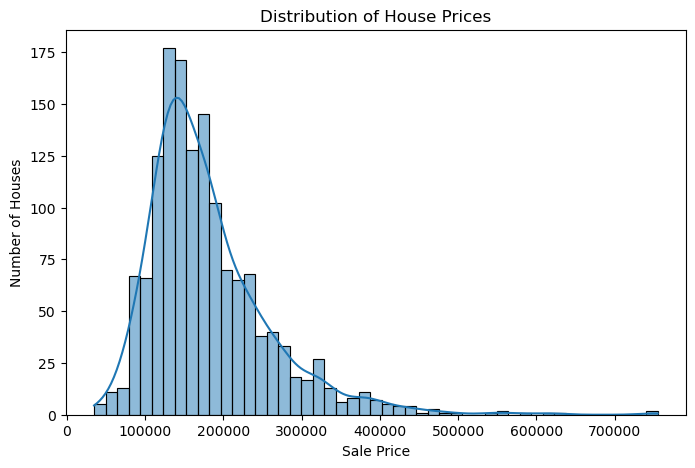

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(train_set["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

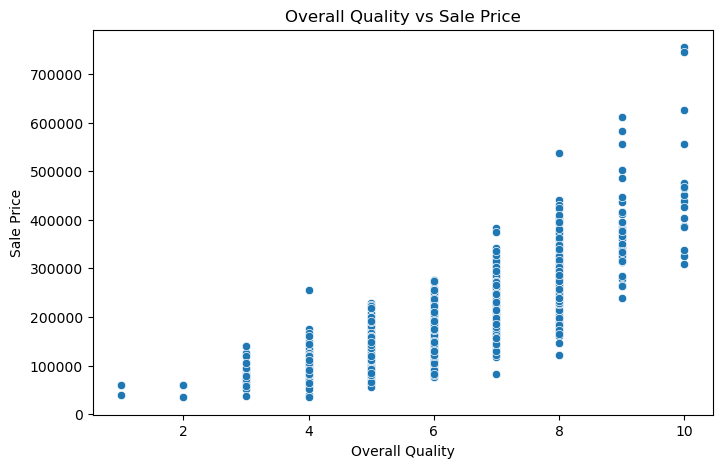

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="OverallQual", y="SalePrice", data=train_set)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.show()

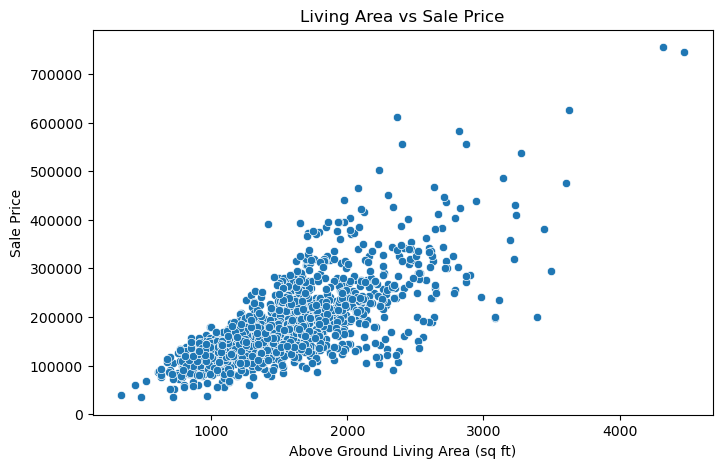

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=train_set)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()

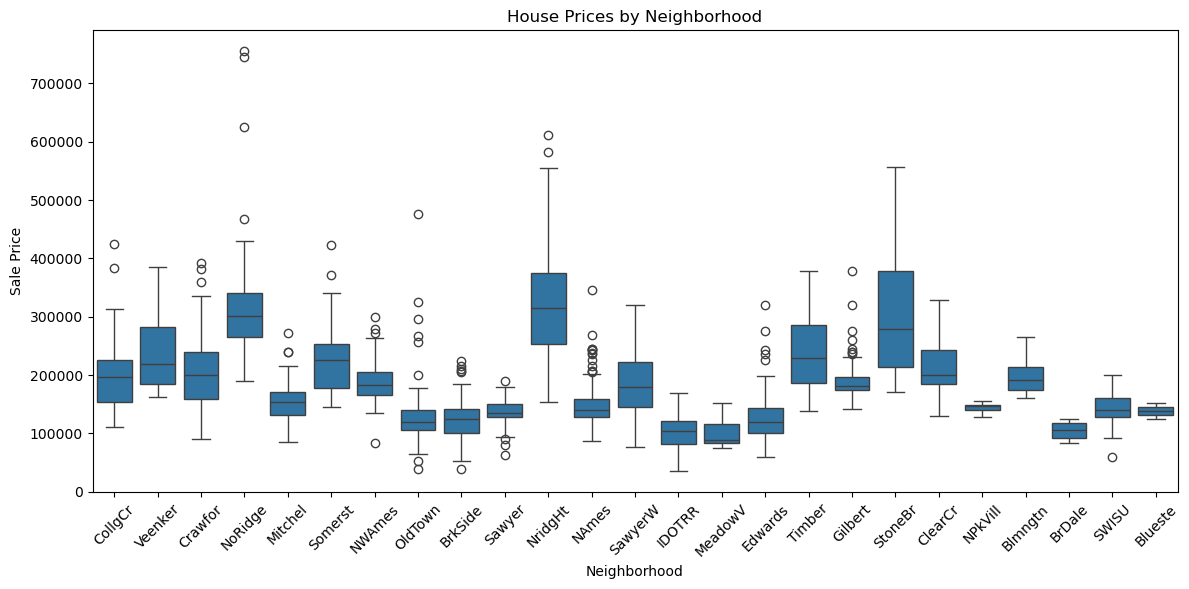

In [26]:
plt.figure(figsize=(14,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=train_set)

plt.title("House Prices by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")
plt.xticks(rotation=45)

plt.show()

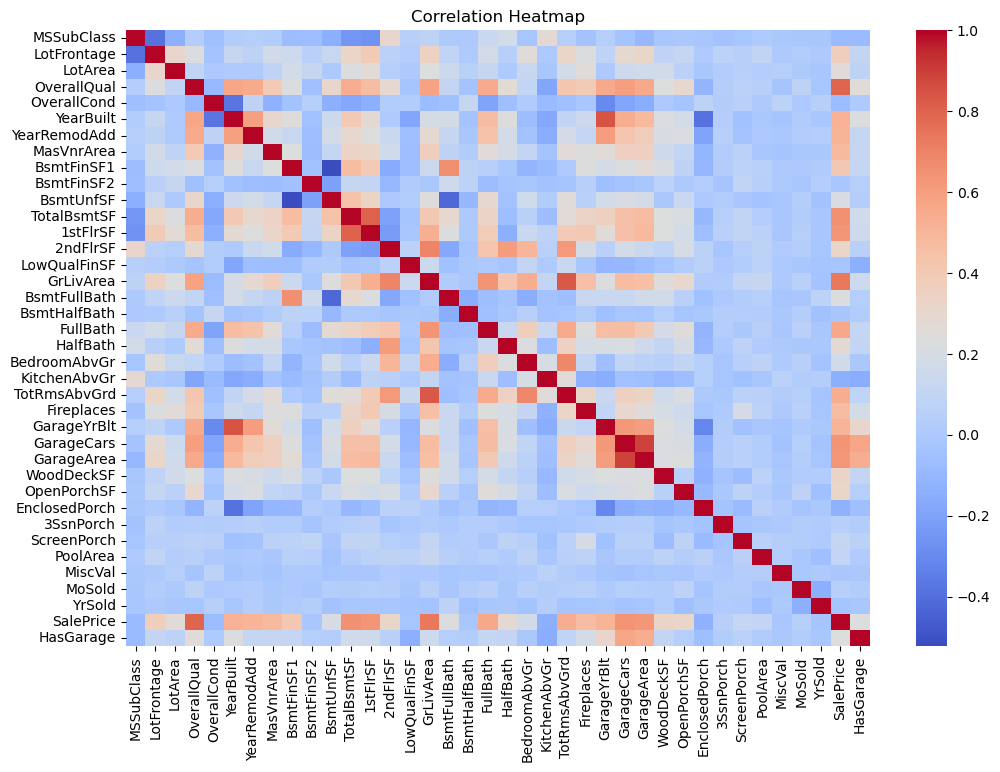

In [27]:
plt.figure(figsize=(12,8))

correlation = train_set.select_dtypes(include="number").corr()

sns.heatmap(correlation, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

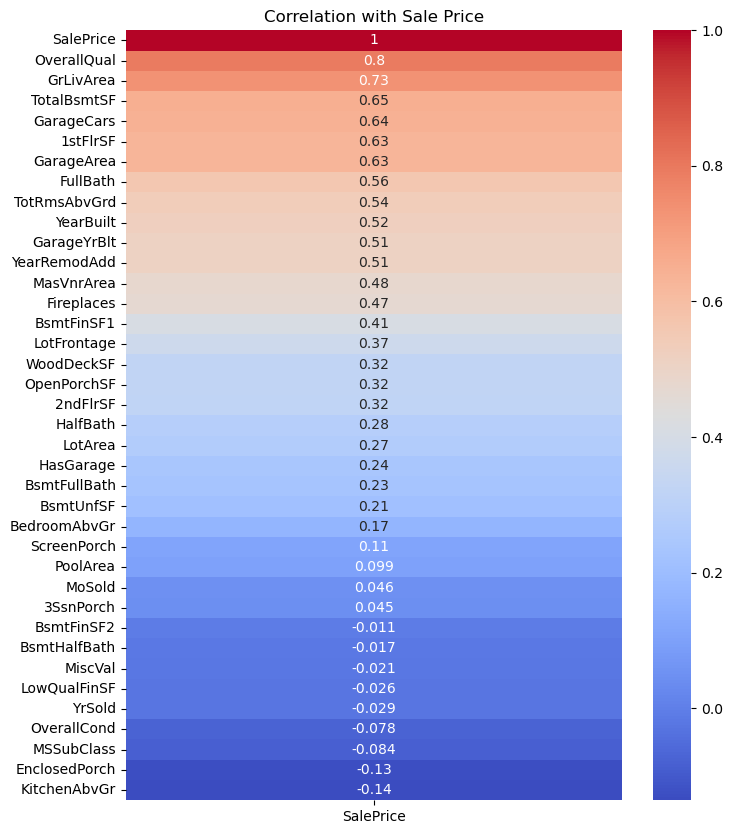

In [28]:
price_corr = train_set.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(price_corr.to_frame(), annot=True, cmap="coolwarm")

plt.title("Correlation with Sale Price")
plt.show()

### Separate Features and Target

In [30]:
x = train_set.drop("SalePrice", axis=1)
y = train_set["SalePrice"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (1458, 76)
y shape: (1458,)


### Train-Validation Split

In [32]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val= train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

In [33]:
print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

x_train: (1166, 76)
x_val: (292, 76)
y_train: (1166,)
y_val: (292,)


### Identify Numerical and Categorical Features

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [36]:
numerical_cols = x_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = x_train.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 36
Categorical columns: 39


### Encode Categorical Features

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [39]:
x_train_encoded = preprocessor.fit_transform(x_train)

In [40]:
x_val_encoded = preprocessor.transform(x_val)

In [41]:
print("x_train_encoded:", x_train_encoded.shape)
print("x_val_encoded:", x_val_encoded.shape)

x_train_encoded: (1166, 281)
x_val_encoded: (292, 281)


# Model Training

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
results_list = []

def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2


In [44]:
def record_results(model_name, y_true, y_pred):
    mae, rmse, r2 = evaluate_model(y_true, y_pred)
    results_list.append({"Model": model_name, "MAE": mae, "RMSE": rmse, "R² Score": r2})

    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")

In [45]:
def compare_results():
     return pd.DataFrame(results_list).sort_values("RMSE").reset_index(drop=True)

## Baseline Linear Regression Model

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
model= LinearRegression()
model.fit(x_train_encoded, y_train)

LinearRegression()

In [49]:
y_pred = model.predict(x_val_encoded)
comparison = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual      Predicted
0  190000  246190.270566
1  100000   86982.628048
2  115000   91923.468509
3  159000  180924.012792
4  315500  330895.517751
5  137500  149818.769466
6  311500  232832.958771
7  310000  315799.369967
8  281000  315880.544393
9  135500  148337.782052


### Baseline Model Evaluation

In [51]:
record_results("Baseline Linear Regression", y_val, y_pred)

compare_results()

--- Baseline Linear Regression ---
MAE:  17,428.77
RMSE: 23,998.89
R²:   0.8957


,Model,MAE,RMSE,R² Score
0,Baseline Linear Regression,17428.766361,23998.893357,0.895732


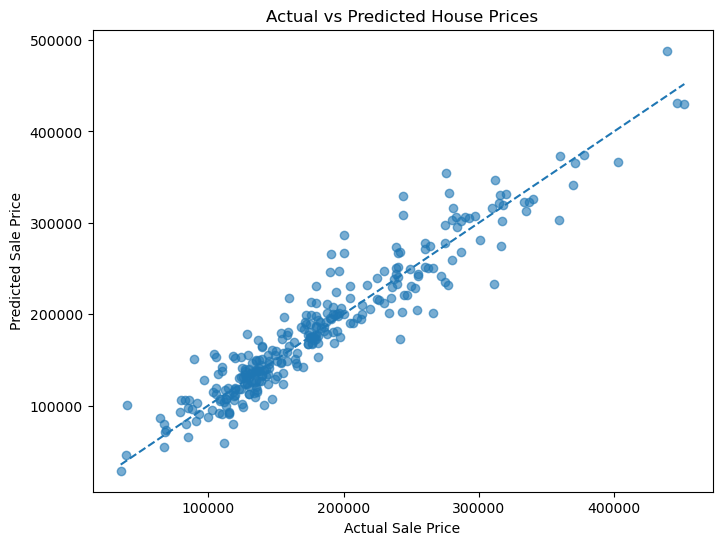

In [52]:
# Plot actual prices against predicted prices
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred, alpha=0.6)

# Add a reference line representing perfect predictions
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.show()

### Interpretation

The Actual vs Predicted plot helps identify how closely the model's predictions follow the actual house prices. Points close to the diagonal reference line represent accurate predictions, while points farther away indicate larger prediction errors.

### Baseline Model Conclusion

The Linear Regression model provides a strong baseline for predicting house prices. However, the prediction errors shown by the MAE and RMSE indicate that there is room for improvement. The next stage of the project will focus on improving model performance and comparing different regression algorithms.

## Log Transformation of SalePrice
SalePrice is right-skewed, meaning that a relatively small number of expensive houses create a long tail in the distribution. A logarithmic transformation is applied to reduce this skewness and make the target distribution more balanced.

In [56]:
# Apply log transformation to reduce the skewness of SalePrice
y_log = np.log1p(y)

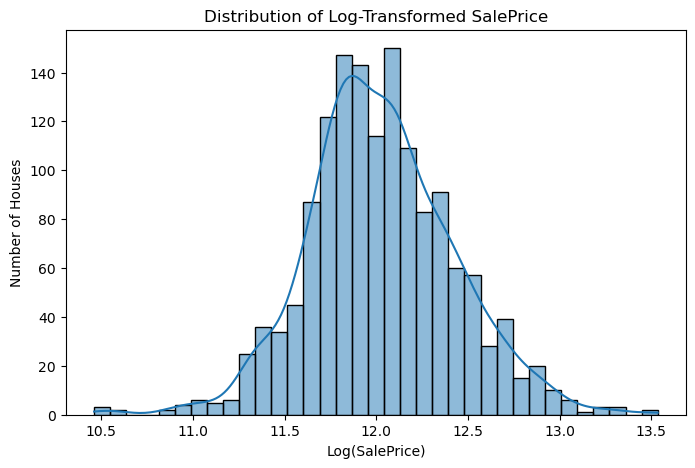

In [57]:
# Visualize the distribution of the log-transformed target
plt.figure(figsize=(8, 5))

sns.histplot(y_log, kde=True)

plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Number of Houses")

plt.show()

In [58]:
# Apply log transformation to the target variable
y_log_train = np.log1p(y_train)
y_log_val = np.log1p(y_val)

print("Original training target:")
print(y_train.head())

print("\nLog-transformed training target:")
print(y_log_train.head())

Original training target:
254     145000
1065    178000
864     148500
798     175000
380     127000
Name: SalePrice, dtype: int64

Log-transformed training target:
254     11.884496
1065    12.089544
864     11.908347
798     12.072547
380     11.751950
Name: SalePrice, dtype: float64


In [59]:
log_model = LinearRegression()
log_model.fit(x_train_encoded, y_log_train)

LinearRegression()

In [60]:
# Predict log-transformed house prices
y_log_pred = log_model.predict(x_val_encoded)

print(y_log_pred[:10])

[12.30847436 11.51323317 11.48911419 12.01130472 12.66794212 11.90235458
 12.39135368 12.67960422 12.57527466 11.85243406]


In [61]:
# Convert log-transformed predictions back to the original price scale
y_pred_log_model = np.expm1(y_log_pred)

print(y_pred_log_model[:10])

[221564.68336702 100029.77505915  97645.99723943 164604.12730156
 317406.62940491 147612.78463684 240710.32666248 321129.93650158
 289314.96038008 140424.7359359 ]


### Log-Transformed Model Results


In [63]:
record_results("Log-Transformed Linear Regression", y_val, y_pred_log_model)

--- Log-Transformed Linear Regression ---
MAE:  14,666.76
RMSE: 20,750.18
R²:   0.9221


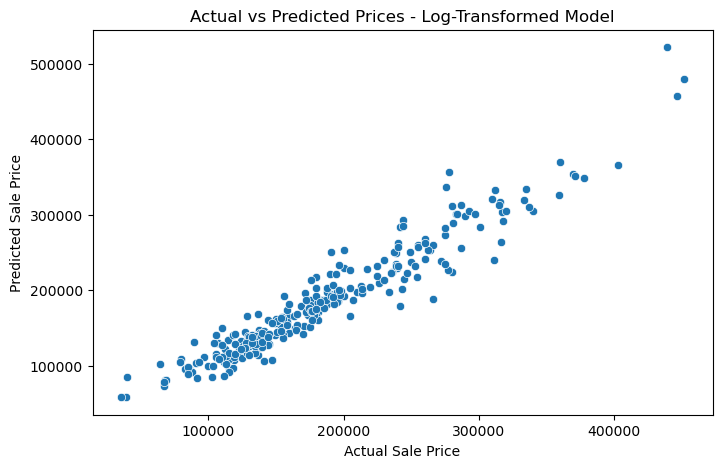

In [64]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_val, y=y_pred_log_model)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Prices - Log-Transformed Model")

plt.show()

### Model Comparison

In [66]:
compare_results()

,Model,MAE,RMSE,R² Score
0,Log-Transformed Linear Regression,14666.755485,20750.175518,0.922051
1,Baseline Linear Regression,17428.766361,23998.893357,0.895732


Although the log-transformed Linear Regression model performs well, other regression algorithms may capture nonlinear relationships between the features and house prices more effectively.

In this section, different regression models will be trained and evaluated using the same validation dataset and evaluation metrics. Their performance will then be compared to identify the best-performing model.

## Random Forest Model

In [69]:
from sklearn.ensemble import RandomForestRegressor

In [70]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train_encoded, y_log_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [71]:
# Make predictions using Random Forest
y_rf_log_pred = rf_model.predict(x_val_encoded)
y_rf_pred = np.expm1(y_rf_log_pred)

print(y_rf_pred[:10])

[210255.41073657  93700.48349534 113052.05117845 149840.66336886
 311712.12077224 144635.91878605 211794.32290185 291181.97807794
 279989.82430228 133799.78548729]


### Random Forest Model Result

In [73]:
record_results("Random Forest (log target)", y_val, y_rf_pred)

--- Random Forest (log target) ---
MAE:  16,346.32
RMSE: 23,906.78
R²:   0.8965


### Model Comparison

In [75]:
compare_results()

,Model,MAE,RMSE,R² Score
0,Log-Transformed Linear Regression,14666.755485,20750.175518,0.922051
1,Random Forest (log target),16346.317799,23906.775891,0.896531
2,Baseline Linear Regression,17428.766361,23998.893357,0.895732


The log-transformed Linear Regression model is the strongest performer across all three metrics, explaining approximately 92.2% of the variance in house prices. Random Forest slightly outperforms the untransformed baseline but does not beat the log-transformed linear model — suggesting that, for this dataset, correcting the target's skew mattered more than the added model complexity of an ensemble method.

## Ridge and Lasso Regression

In [78]:
from sklearn.preprocessing import StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

x_train_scaled = preprocessor_scaled.fit_transform(x_train)
x_val_scaled = preprocessor_scaled.transform(x_val)

In [79]:
from sklearn.linear_model import RidgeCV, LassoCV

alphas = np.logspace(-3, 3, 50)  # tests 50 values from 0.001 to 1000

ridge_model = RidgeCV(alphas=alphas)
ridge_model.fit(x_train_scaled, y_log_train)
print("Best Ridge alpha:", ridge_model.alpha_)

lasso_model = LassoCV(alphas=alphas, max_iter=5000, random_state=42)
lasso_model.fit(x_train_scaled, y_log_train)
print("Best Lasso alpha:", lasso_model.alpha_)

Best Ridge alpha: 19.306977288832496
Best Lasso alpha: 0.001


In [139]:
###  Model Result

In [80]:
y_ridge_pred = np.expm1(ridge_model.predict(x_val_scaled))
record_results("Ridge Regression (log target)", y_val, y_ridge_pred)

--- Ridge Regression (log target) ---
MAE:  14,505.01
RMSE: 19,923.49
R²:   0.9281


In [81]:
y_lasso_pred = np.expm1(lasso_model.predict(x_val_scaled))
record_results("Lasso Regression (log target)", y_val, y_lasso_pred)

--- Lasso Regression (log target) ---
MAE:  14,064.20
RMSE: 19,341.65
R²:   0.9323


### Model Comparison

In [82]:
compare_results()

,Model,MAE,RMSE,R² Score
0,Lasso Regression (log target),14064.201561,19341.647737,0.932274
1,Ridge Regression (log target),14505.014004,19923.486802,0.928138
2,Log-Transformed Linear Regression,14666.755485,20750.175518,0.922051
3,Random Forest (log target),16346.317799,23906.775891,0.896531
4,Baseline Linear Regression,17428.766361,23998.893357,0.895732


Lasso Regression is the best-performing model so far, improving on the unregularized log-transformed model across all three metrics and explaining approximately 93.2% of the variance in house prices. Since Lasso can shrink coefficients to exactly zero, this improvement suggests that some of the 283 one-hot-encoded features add noise rather than signal, and that penalizing them out benefits generalization more than the added complexity of an ensemble method like Random Forest does.

In [143]:
zeroed = np.sum(lasso_model.coef_ == 0)
total = len(lasso_model.coef_)
print(f"Lasso zeroed out {zeroed} of {total} features ({zeroed/total:.1%})")

Lasso zeroed out 198 of 281 features (70.5%)


## Final Conclusion- Why Lasso Regression performed best 

Lasso's feature selection was aggressive: 198 of 281 features (70.5%) were shrunk to exactly zero, meaning the model relies on just 83 features to achieve its best performance — evidence that much of the one-hot-encoded categorical expansion contributed noise rather than predictive signal.